In [ ]:
# Installer la librairie yfinance
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Télécharger les données des 3 banques (2 ans)
bnp = yf.download('BNP.PA', start='2024-04-01', end='2026-04-26')
socgen = yf.download('GLE.PA', start='2024-04-01', end='2026-04-26')
santander = yf.download('SAN.MC', start='2024-04-01', end='2026-04-26')

# Voir à quoi ça ressemble
print("BNP Paribas:")
print(bnp.head())
print("\nShape:", bnp.shape)


/tmp/ipykernel_15675/1901602623.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bnp = yf.download('BNP.PA', start='2024-04-01', end='2026-04-26')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_15675/1901602623.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  socgen = yf.download('GLE.PA', start='2024-04-01', end='2026-04-26')
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_15675/1901602623.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  santander = yf.download('SAN.MC', start='2024-04-01', end='2026-04-26')
[*********************100%***********************]  1 of 1 completed

BNP Paribas:
Price           Close       High        Low       Open   Volume
Ticker         BNP.PA     BNP.PA     BNP.PA     BNP.PA   BNP.PA
Date                                                           
2024-04-02  55.692001  56.696535  55.487691  56.015499  2995647
2024-04-03  56.636948  56.943416  55.581338  55.674982  3081188
2024-04-04  57.173267  57.547835  56.866799  56.866799  2583051
2024-04-05  56.653976  56.764643  56.109145  56.381561  2913205
2024-04-08  57.028542  57.300957  56.585869  56.628430  1847356

Shape: (527, 5)


In [ ]:
# Sauvegarder en CSV (attention aux MINUSCULES)
bnp.to_csv('bnp.csv')
socgen.to_csv('socgen.csv')
santander.to_csv('santander.csv')

print("Files saved!")

Files saved!


# New section

In [ ]:
# Calculer les rendements quotidiens (variation en %)
bnp['Daily_Return'] = bnp['Close'].pct_change() * 100
socgen['Daily_Return'] = socgen['Close'].pct_change() * 100
santander['Daily_Return'] = santander['Close'].pct_change() * 100

# Calculer les rendements cumulés (performance totale depuis le début)
bnp['Cumulative_Return'] = (bnp['Close'] / bnp['Close'].iloc[0] - 1) * 100
socgen['Cumulative_Return'] = (socgen['Close'] / socgen['Close'].iloc[0] - 1) * 100
santander['Cumulative_Return'] = (santander['Close'] / santander['Close'].iloc[0] - 1) * 100

# Vérifier le résultat sur BNP
print("BNP Paribas — avec rendements:")
print(bnp.tail())

BNP Paribas — avec rendements:
Price           Close       High        Low       Open   Volume  Daily_Return  \
Date                                                                            
2026-04-20  92.599998  93.559998  91.269997  92.500000  1848965     -1.781927   
2026-04-21  92.139999  93.480003  91.790001  93.180000  1496582     -0.496759   
2026-04-22  90.739998  92.500000  90.629997  92.110001  1676547     -1.519429   
2026-04-23  90.309998  90.480003  88.389999  90.000000  1791662     -0.473882   
2026-04-24  89.010002  89.720001  88.269997  88.779999  2024791     -1.439481   

Price       Cumulative_Return  
Date                           
2026-04-20          66.271630  
2026-04-21          65.445660  
2026-04-22          62.931832  
2026-04-23          62.159727  
2026-04-24          59.825469  


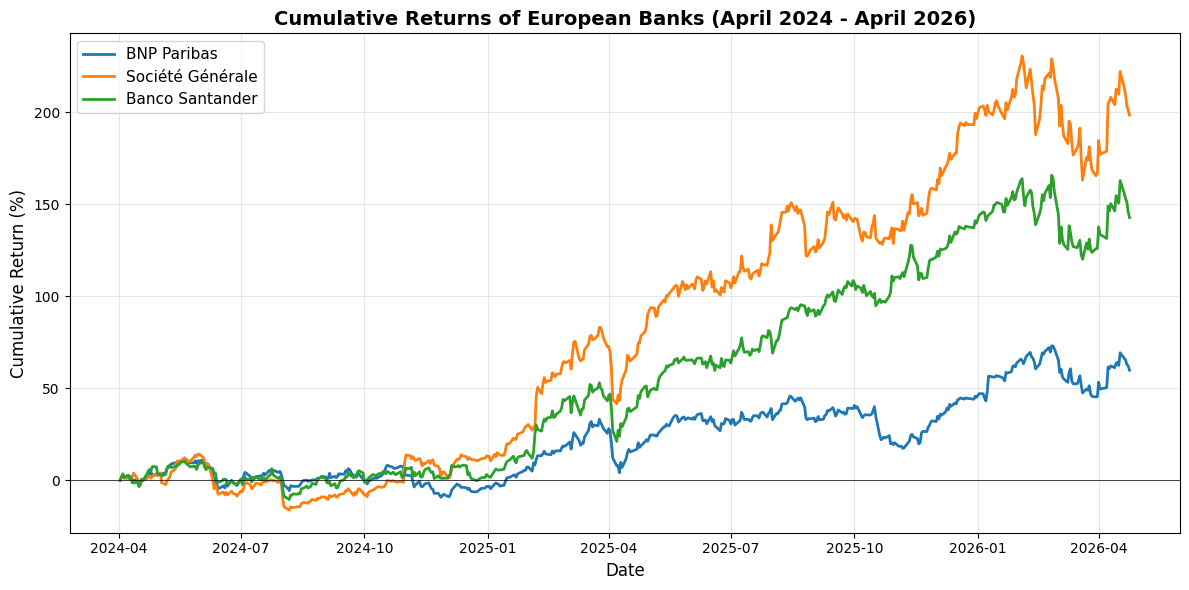

In [ ]:
# Graphique : Évolution des rendements cumulés
plt.figure(figsize=(12, 6))

plt.plot(bnp.index, bnp['Cumulative_Return'], label='BNP Paribas', linewidth=2)
plt.plot(socgen.index, socgen['Cumulative_Return'], label='Société Générale', linewidth=2)
plt.plot(santander.index, santander['Cumulative_Return'], label='Banco Santander', linewidth=2)

plt.title('Cumulative Returns of European Banks (April 2024 - April 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Cumulative Return (%)', fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('cumulative_returns.png', dpi=150, bbox_inches='tight')
plt.show()

=== ANNUALIZED VOLATILITY (Risk) ===

BNP Paribas:        26.87%
Société Générale:   34.76%
Banco Santander:    30.97%


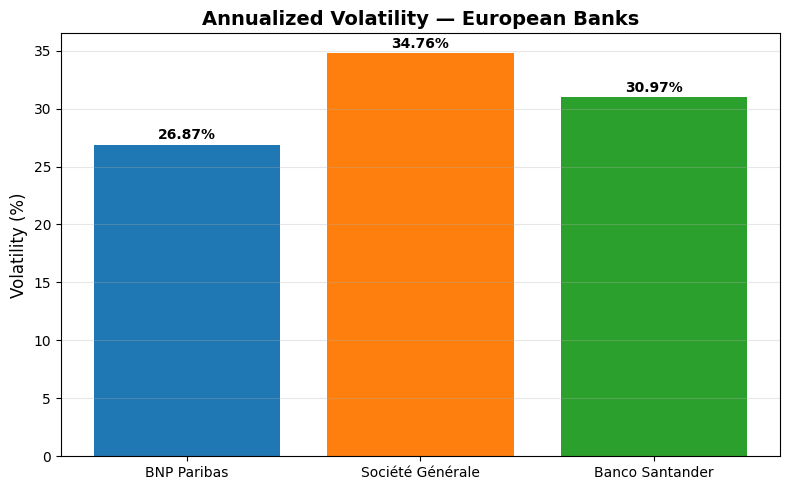

In [ ]:
# Calculer la volatilité (= risque) de chaque banque
print("=== ANNUALIZED VOLATILITY (Risk) ===\n")

vol_bnp = bnp['Daily_Return'].std() * (252 ** 0.5)
vol_socgen = socgen['Daily_Return'].std() * (252 ** 0.5)
vol_santander = santander['Daily_Return'].std() * (252 ** 0.5)

print(f"BNP Paribas:        {vol_bnp:.2f}%")
print(f"Société Générale:   {vol_socgen:.2f}%")
print(f"Banco Santander:    {vol_santander:.2f}%")

# Graphique en barres pour comparer la volatilité
plt.figure(figsize=(8, 5))
banks = ['BNP Paribas', 'Société Générale', 'Banco Santander']
vols = [vol_bnp, vol_socgen, vol_santander]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.bar(banks, vols, color=colors)
plt.title('Annualized Volatility — European Banks', fontsize=14, fontweight='bold')
plt.ylabel('Volatility (%)', fontsize=12)
plt.grid(True, axis='y', alpha=0.3)

# Ajouter les valeurs au-dessus de chaque barre
for i, v in enumerate(vols):
    plt.text(i, v + 0.5, f'{v:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('volatility.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Tableau récapitulatif : Performance vs Risque
import pandas as pd

summary = pd.DataFrame({
    'Bank': ['BNP Paribas', 'Société Générale', 'Banco Santander'],
    'Cumulative Return (%)': [
        bnp['Cumulative_Return'].iloc[-1],
        socgen['Cumulative_Return'].iloc[-1],
        santander['Cumulative_Return'].iloc[-1]
    ],
    'Annualized Volatility (%)': [vol_bnp, vol_socgen, vol_santander],
    'Return / Risk Ratio': [
        bnp['Cumulative_Return'].iloc[-1] / vol_bnp,
        socgen['Cumulative_Return'].iloc[-1] / vol_socgen,
        santander['Cumulative_Return'].iloc[-1] / vol_santander
    ]
})

# Arrondir à 2 décimales
summary = summary.round(2)

print("=== SUMMARY: PERFORMANCE vs RISK ===\n")
print(summary.to_string(index=False))

# Sauvegarder en CSV pour le README
summary.to_csv('summary.csv', index=False)
print("\n✅ Summary saved to summary.csv")

=== SUMMARY: PERFORMANCE vs RISK ===

            Bank  Cumulative Return (%)  Annualized Volatility (%)  Return / Risk Ratio
     BNP Paribas                  59.83                      26.87                 2.23
Société Générale                 198.43                      34.76                 5.71
 Banco Santander                 142.77                      30.97                 4.61

✅ Summary saved to summary.csv


In [16]:
# Créer un zip de tous les fichiers du projet
import shutil

# Créer le dossier
import os
os.makedirs('european_banks_project', exist_ok=True)

# Copier les fichiers dedans
files = ['cumulative_returns.png', 'volatility.png', 'summary.csv']
for f in files:
    if os.path.exists(f):
        shutil.copy(f, f'european_banks_project/{f}')

# Créer le zip
shutil.make_archive('european_banks_project', 'zip', 'european_banks_project')

# Téléchargement automatique
from google.colab import files
files.download('european_banks_project.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>